In [1]:
import requests
# weather dataset of a month making 2025-2026 trend

import pandas as pd

In [5]:
import requests   # API call ke liye
import pandas as pd   # dataset banane ke liye

API_KEY = "b09cd896557f7af5351c365151e3d093"

city = "Delhi"

url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"

response = requests.get(url)

data = response.json()

print(data)

{'cod': 401, 'message': 'Invalid API key. Please see https://openweathermap.org/faq#error401 for more info.'}


In [5]:
!pip install -U meteostat pandas matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import meteostat as ms
from datetime import date

# Ranchi
POINT = ms.Point(23.3441, 85.3096)

START = date(2025, 1, 1)
END = date(2025, 5, 31)

stations = ms.stations.nearby(POINT, limit=4)
ts = ms.daily(stations, START, END)
df = ms.interpolate(ts, POINT).fetch()

df.head()

,temp,tmin,tmax,rhum,prcp,wspd,pres,cldc
time,,,,,,,,
2025-01-01,14.7,9.0,21.2,66,0.0,8.4,1017.5,1
2025-01-02,13.4,6.0,20.6,68,0.0,8.4,1017.4,0
2025-01-03,14.2,8.0,22.6,65,0.0,5.9,1017.5,0
2025-01-04,15.0,8.0,24.2,69,0.0,1.8,1016.6,0
2025-01-05,16.0,8.0,24.4,74,0.0,3.0,1016.8,0


In [29]:
df.shape

(151, 8)

In [3]:
!pip show meteostat

Name: meteostat
Version: 2.1.4
Summary: Access and analyze historical weather and climate data with Python.
Home-page: 
Author: Meteostat
Author-email: 
License: 
Location: D:\programming\programming\python\age&genderdetection\detectron2_env\Lib\site-packages
Requires: pandas, pytz, requests
Required-by: 


In [31]:
import pandas as pd

# load CSV
df = pd.read_csv(r"C:\Users\ka843\Coding\Python_Masterclass\weather2025.csv")

# convert date
df["time"] = pd.to_datetime(df["time"])

# rename for clarity
df.rename(columns={
    "time": "Date",
    "temp": "Avg Temp",
    "tmin": "Min Temp",
    "tmax": "Max Temp",
    "rhum": "Humidity",
    "prcp": "Rain",
    "wspd": "Wind Speed",
    "pres": "Pressure",
    "cldc": "Cloud"
}, inplace=True)

df.head(20)

,Date,Avg Temp,Min Temp,Max Temp,Humidity,Rain,Wind Speed,Pressure,Cloud
0,2025-01-01,14.7,9.0,21.2,66,0.0,8.4,1017.5,1.0
1,2025-01-02,13.4,6.0,20.6,68,0.0,8.4,1017.4,0.0
2,2025-01-03,14.2,8.0,22.6,65,0.0,5.9,1017.5,0.0
3,2025-01-04,15.0,8.0,24.2,69,0.0,1.8,1016.6,0.0
4,2025-01-05,16.0,8.0,24.4,74,0.0,3.0,1016.8,0.0
5,2025-01-06,16.7,8.0,24.4,73,0.0,2.9,1015.8,1.0
6,2025-01-07,15.5,11.0,22.4,76,0.0,8.0,1015.4,0.0
7,2025-01-08,13.9,8.0,21.4,64,0.0,7.5,1016.4,0.0
8,2025-01-09,13.2,6.0,22.0,71,0.0,3.7,1018.8,0.0
9,2025-01-10,14.0,6.0,23.0,62,0.0,5.0,1020.2,0.0


In [32]:
df.shape

(151, 9)

In [33]:
print(len(df))

151


In [36]:
df.isnull().sum()/ len(df) * 100

Date          0.000000
Avg Temp      0.000000
Min Temp      0.000000
Max Temp      0.000000
Humidity      0.000000
Rain          3.973510
Wind Speed    0.000000
Pressure      4.635762
Cloud         3.973510
dtype: float64

In [37]:
def get_condition(row):
    if row["Rain"] > 0:
        return "Rainy"
    elif row["Avg Temp"] < 15:
        return "Cold"
    elif row["Cloud"] > 5:
        return "Cloudy"
    else:
        return "Sunny"

df["Condition"] = df.apply(get_condition, axis=1)

df.head()

,Date,Avg Temp,Min Temp,Max Temp,Humidity,Rain,Wind Speed,Pressure,Cloud,Condition
0,2025-01-01,14.7,9.0,21.2,66,0.0,8.4,1017.5,1.0,Cold
1,2025-01-02,13.4,6.0,20.6,68,0.0,8.4,1017.4,0.0,Cold
2,2025-01-03,14.2,8.0,22.6,65,0.0,5.9,1017.5,0.0,Cold
3,2025-01-04,15.0,8.0,24.2,69,0.0,1.8,1016.6,0.0,Sunny
4,2025-01-05,16.0,8.0,24.4,74,0.0,3.0,1016.8,0.0,Sunny


In [38]:
color_map = {
    "Sunny": "orange",
    "Rainy": "blue",
    "Cold": "cyan",
    "Cloudy": "gray"
}

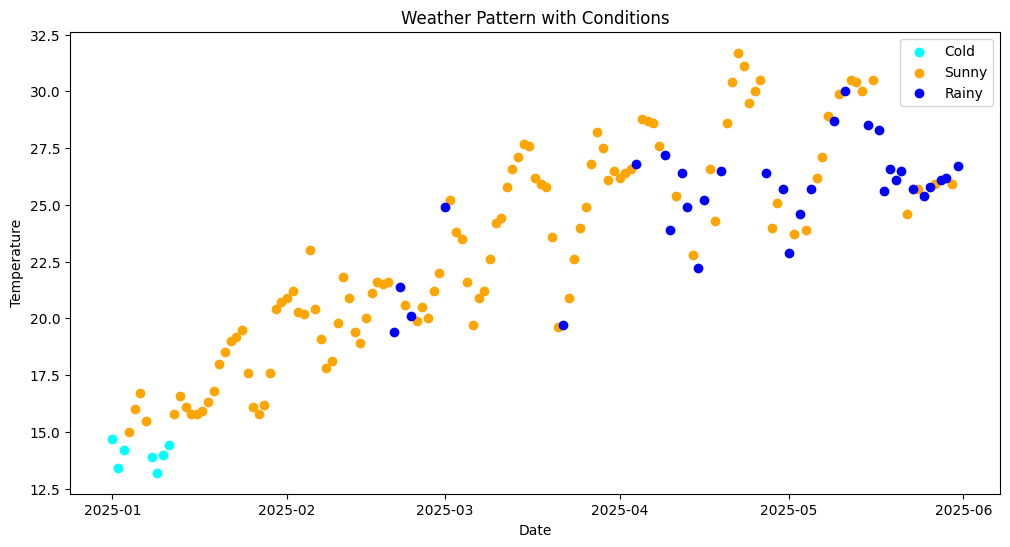

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for condition in df["Condition"].unique():
    subset = df[df["Condition"] == condition]
    
    plt.scatter(
        subset["Date"],
        subset["Avg Temp"],
        label=condition,
        color=color_map[condition]
    )

plt.legend()
plt.title("Weather Pattern with Conditions")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

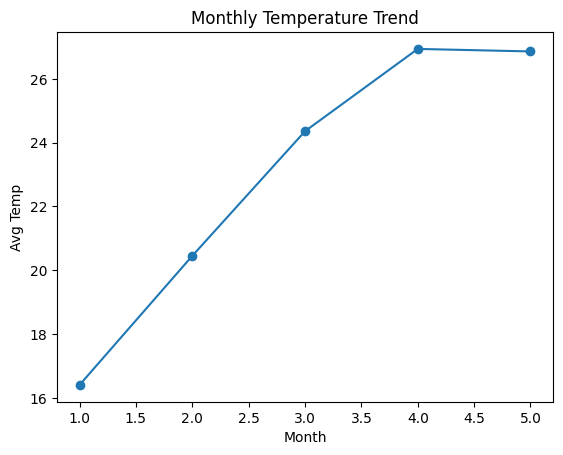

In [40]:
df["Month"] = df["Date"].dt.month

monthly_avg = df.groupby("Month")["Avg Temp"].mean()

monthly_avg.plot(marker="o")
plt.title("Monthly Temperature Trend")
plt.xlabel("Month")
plt.ylabel("Avg Temp")
plt.show()

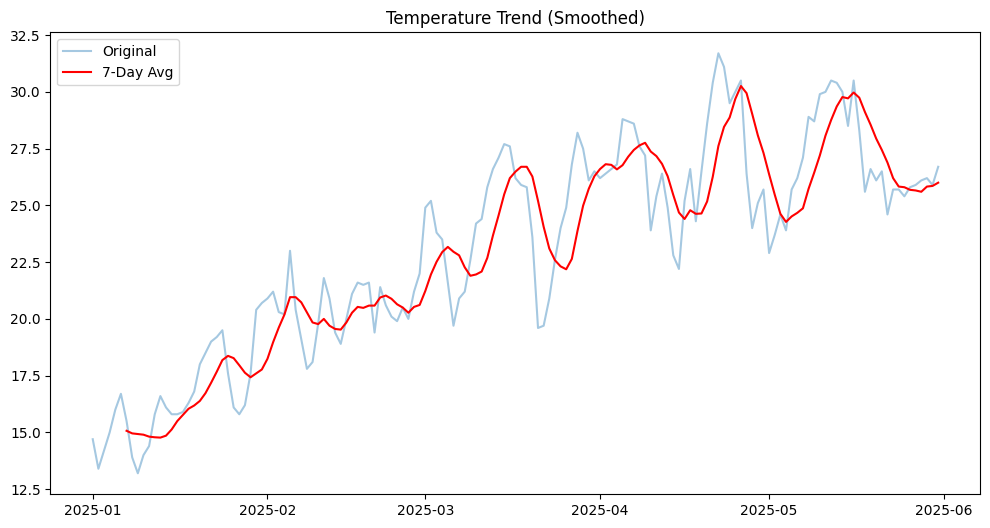

In [ ]:
df["Rolling Temp"] = df["Avg Temp"].rolling(window=30).mean()

plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Avg Temp"], alpha=0.4, label="Original")
plt.plot(df["Date"], df["Rolling Temp"], color="red", label="7-Day Avg")

plt.legend()
plt.title("Temperature Trend (Smoothed)")
plt.show()

In [19]:
df.to_csv("clean_weather_2026.csv", index=False)